In [2]:
%%writefile normal.cpp
#include <iostream>
#include <chrono>
#include <vector>
#include <cstdlib>

int main(int argc, char* argv[]) {
    if (argc < 2) return 1;
    long long n = std::atoll(argv[1]);

    std::vector<int> arr(n, 1);
    volatile long long sum = 0; 

    auto start = std::chrono::high_resolution_clock::now();
    for (long long i = 0; i < n; ++i) {
        sum += arr[i];
    }
    auto end = std::chrono::high_resolution_clock::now();
    
    auto time = std::chrono::duration_cast<std::chrono::nanoseconds>(end - start);
    std::cout << time.count() << std::endl;

    return 0;
}

Writing normal.cpp


In [1]:
%%writefile random.cpp
#include <iostream>
#include <chrono>
#include <vector>
#include <numeric>
#include <random>
#include <algorithm>
#include <cstdlib>

int main(int argc, char* argv[]) {
    if (argc < 2) return 1;
    long long n = std::atoll(argv[1]);

    std::vector<int> arr(n, 1);
    std::vector<int> indices(n);
    std::iota(indices.begin(), indices.end(), 0);

    std::random_device rd;
    std::mt19937 gen(rd());
    std::shuffle(indices.begin(), indices.end(), gen);

    volatile long long sum = 0;

    auto start = std::chrono::high_resolution_clock::now();
    for (long long i = 0; i < n; ++i) {
        sum += arr[indices[i]];
    }
    auto end = std::chrono::high_resolution_clock::now();
    
    auto time = std::chrono::duration_cast<std::chrono::nanoseconds>(end - start);
    std::cout << time.count() << std::endl;

    return 0;
}

Writing random.cpp


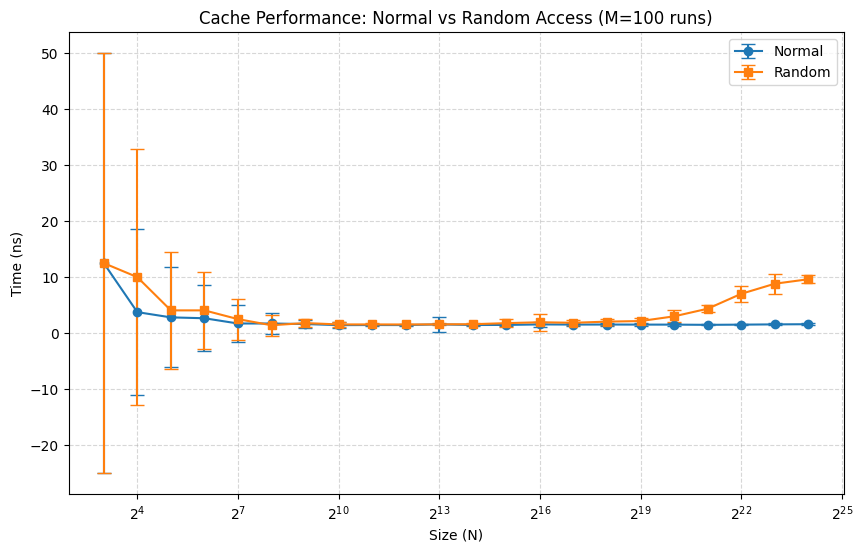

In [7]:
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import os


bin_normal = "normal_bin.exe" if os.name == 'nt' else "./normal_bin"
bin_random = "random_bin.exe" if os.name == 'nt' else "./random_bin"

subprocess.run(["g++", "-O3", "normal.cpp", "-o", bin_normal.replace('./', '')])
subprocess.run(["g++", "-O3", "random.cpp", "-o", bin_random.replace('./', '')])

#N_values are the sizes of the arrays we want to test, M is the number of repetitions for each test
N_values = [2**i for i in range(3, 25)]
M = 100                                    

results_normal_mean, results_normal_std = [], []
results_random_mean, results_random_std = [], []


for n in N_values:
    times_normal = []
    times_random = []

    for _ in range(M):
        res_norm = subprocess.run([bin_normal, str(n)], capture_output=True, text=True)
        vrijeme_po_elementu_norm = int(res_norm.stdout.strip()) / n
        times_normal.append(vrijeme_po_elementu_norm)

        res_rand = subprocess.run([bin_random, str(n)], capture_output=True, text=True)
        vrijeme_po_elementu_rand = int(res_rand.stdout.strip()) / n
        times_random.append(vrijeme_po_elementu_rand)

    results_normal_mean.append(np.mean(times_normal))
    results_normal_std.append(np.std(times_normal))
    
    results_random_mean.append(np.mean(times_random))
    results_random_std.append(np.std(times_random))


plt.figure(figsize=(10, 6))

plt.errorbar(N_values, results_normal_mean, yerr=results_normal_std, 
             label='Normal', fmt='-o', capsize=5)
plt.errorbar(N_values, results_random_mean, yerr=results_random_std, 
             label='Random', fmt='-s', capsize=5)

plt.xscale('log', base=2)
plt.xlabel('Size (N)')
plt.ylabel('Time (ns)')
plt.title(f'Cache Performance: Normal vs Random Access (M={M} runs)')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.show()

In [8]:
%%writefile stride_test.cpp
#include <iostream>
#include <chrono>
#include <vector>
#include <cstdlib>

int main(int argc, char* argv[]) {
    if (argc < 3) return 1;
    
    long long n = std::atoll(argv[1]);
    long long stride = std::atoll(argv[2]);

    std::vector<int> arr(n, 1);
    volatile long long sum = 0;

    long long accesses = n / stride;
    if (accesses == 0) return 0;

    auto start = std::chrono::high_resolution_clock::now();
    

    for (long long i = 0; i < n; i += stride) {
        sum += arr[i];
    }
    
    auto end = std::chrono::high_resolution_clock::now();
    
    auto time = std::chrono::duration_cast<std::chrono::nanoseconds>(end - start);
    
    std::cout << time.count() << " " << accesses << std::endl;

    return 0;
}

Writing stride_test.cpp


Finished for stride = 1
Finished for stride = 2
Finished for stride = 4
Finished for stride = 8
Finished for stride = 16
Finished for stride = 32
Finished for stride = 64
Finished for stride = 128
Finished for stride = 256
Finished for stride = 512
Finished for stride = 1024
Finished for stride = 2048


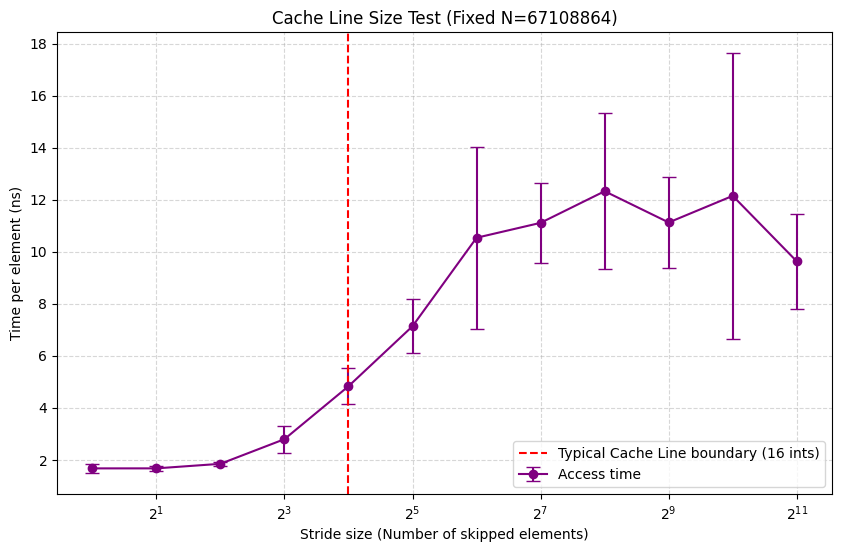

In [1]:
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import os

bin_stride = "stride_test.exe" if os.name == 'nt' else "./stride_test"
subprocess.run(["g++", "-O3", "stride_test.cpp", "-o", bin_stride.replace('./', '')])

N_fixed = 2**26 
strides = [2**i for i in range(0, 12)]
M = 10

results_mean = []
results_std = []

for stride in strides:
    times_per_access = []
    
    for _ in range(M):
        res = subprocess.run([bin_stride, str(N_fixed), str(stride)], capture_output=True, text=True)
        
        out_parts = res.stdout.strip().split()
        if len(out_parts) == 2:
            total_time = int(out_parts[0])
            accesses = int(out_parts[1])
            time_per_element = total_time / accesses
            times_per_access.append(time_per_element)
            
    results_mean.append(np.mean(times_per_access))
    results_std.append(np.std(times_per_access))
    
    print(f"Finished for stride = {stride}")

plt.figure(figsize=(10, 6))

plt.errorbar(strides, results_mean, yerr=results_std, 
             label='Access time', fmt='-o', color='purple', capsize=5)

plt.xscale('log', base=2)
plt.xlabel('Stride size (Number of skipped elements)')
plt.ylabel('Time per element (ns)')
plt.title(f'Cache Line Size Test (Fixed N={N_fixed})')
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.axvline(x=16, color='red', linestyle='--', label='Typical Cache Line boundary (16 ints)')
plt.legend()

plt.show()